# EDA TABULAR



### Import thư viện và load data

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Load data
df = pd.read_csv('data/raw/Melbourne_housing_FULL.csv')
print(f'Kích thước dữ liệu: {df.shape}')
df.head()

Kích thước dữ liệu: (34857, 21)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0


### Xác định các thuộc tính số (numeric columns)

In [2]:
# Lọc các cột số
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Số lượng thuộc tính số: {len(numeric_cols)}')
print(f'Danh sách các thuộc tính số: {numeric_cols}')
print(f'\nSố lượng mẫu (n): {len(df)}')

Số lượng thuộc tính số: 13
Danh sách các thuộc tính số: ['Rooms', 'Price', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Propertycount']

Số lượng mẫu (n): 34857


### Kiểm định phân phối chuẩn

**Quy tắc chọn kiểm định:**
- **Shapiro-Wilk test**: nếu n ≤ 5000 (mạnh hơn với mẫu nhỏ)
- **D'Agostino-Pearson test**: nếu n > 5000 (phù hợp với mẫu lớn)

**Ngưỡng p-value:** α = 0.05
- p-value > 0.05 → Không bác bỏ H₀ → **Phân phối chuẩn**
- p-value ≤ 0.05 → Bác bỏ H₀ → **Phân phối không chuẩn**

In [3]:
def test_normality(series, alpha=0.05):
    """
    Kiểm định phân phối chuẩn cho một chuỗi dữ liệu.
    - Shapiro-Wilk nếu n <= 5000
    - D'Agostino-Pearson nếu n > 5000
    
    Returns:
        dict: Kết quả kiểm định bao gồm tên kiểm định, statistic, p-value, 
              kết luận phân phối, và phương pháp chuẩn hóa đề xuất.
    """
    # Loại bỏ giá trị NaN
    clean_data = series.dropna()
    n = len(clean_data)
    
    if n < 8:
        return {
            'n_valid': n,
            'test_name': 'N/A',
            'statistic': np.nan,
            'p_value': np.nan,
            'is_normal': None,
            'distribution': 'Không đủ dữ liệu',
            'normalization_method': 'N/A'
        }
    
    if n <= 5000:
        stat, p_value = stats.shapiro(clean_data)
        test_name = 'Shapiro-Wilk'
    else:
        stat, p_value = stats.normaltest(clean_data)  
        test_name = "D'Agostino-Pearson"
    
    is_normal = p_value > alpha
    
    # Lựa chọn phương pháp chuẩn hóa
    if is_normal:
        normalization_method = 'Z-score (StandardScaler)'
    else:
        normalization_method = 'Min-Max hoặc Robust Scaler'
    
    return {
        'n_valid': n,
        'test_name': test_name,
        'statistic': stat,
        'p_value': p_value,
        'is_normal': is_normal,
        'distribution': 'Chuẩn (Normal)' if is_normal else 'Không chuẩn (Non-normal)',
        'normalization_method': normalization_method
    }

In [4]:
# Thực hiện kiểm định cho từng thuộc tính số
results = []

for col in numeric_cols:
    result = test_normality(df[col])
    result['column'] = col
    results.append(result)

# Tạo DataFrame kết quả
results_df = pd.DataFrame(results)
results_df = results_df[['column', 'n_valid', 'test_name', 'statistic', 'p_value', 
                          'distribution', 'normalization_method']]

# Hiển thị kết quả
print('=' * 120)
print('KẾT QUẢ KIỂM ĐỊNH PHÂN PHỐI CHUẨN CHO CÁC THUỘC TÍNH SỐ')
print('=' * 120)
print(f'Ngưỡng alpha = 0.05')
print(f'Tổng số mẫu (n) = {len(df)}')
print(f'=> Sử dụng kiểm định: {"Shapiro-Wilk" if len(df) <= 5000 else "D\'Agostino-Pearson"}')
print('=' * 120)


results_df

KẾT QUẢ KIỂM ĐỊNH PHÂN PHỐI CHUẨN CHO CÁC THUỘC TÍNH SỐ
Ngưỡng alpha = 0.05
Tổng số mẫu (n) = 34857
=> Sử dụng kiểm định: D'Agostino-Pearson


,column,n_valid,test_name,statistic,p_value,distribution,normalization_method
0,Rooms,34857,D'Agostino-Pearson,3356.492772,0.000000e+00,Không chuẩn (Non-normal),Min-Max hoặc Robust Scaler
1,Price,27247,D'Agostino-Pearson,16076.657444,0.000000e+00,Không chuẩn (Non-normal),Min-Max hoặc Robust Scaler
2,Distance,34856,D'Agostino-Pearson,10176.518110,0.000000e+00,Không chuẩn (Non-normal),Min-Max hoặc Robust Scaler
3,Postcode,34856,D'Agostino-Pearson,29374.029372,0.000000e+00,Không chuẩn (Non-normal),Min-Max hoặc Robust Scaler
4,Bedroom2,26640,D'Agostino-Pearson,12352.780650,0.000000e+00,Không chuẩn (Non-normal),Min-Max hoặc Robust Scaler
5,Bathroom,26631,D'Agostino-Pearson,7716.740550,0.000000e+00,Không chuẩn (Non-normal),Min-Max hoặc Robust Scaler
6,Car,26129,D'Agostino-Pearson,14583.102989,0.000000e+00,Không chuẩn (Non-normal),Min-Max hoặc Robust Scaler
7,Landsize,23047,D'Agostino-Pearson,90417.099879,0.000000e+00,Không chuẩn (Non-normal),Min-Max hoặc Robust Scaler
8,BuildingArea,13742,D'Agostino-Pearson,54491.840612,0.000000e+00,Không chuẩn (Non-normal),Min-Max hoặc Robust Scaler
9,YearBuilt,15551,D'Agostino-Pearson,4907.658332,0.000000e+00,Không chuẩn (Non-normal),Min-Max hoặc Robust Scaler


### Thống kê tổng hợp kết quả

In [5]:
# Đếm số thuộc tính phân phối chuẩn và không chuẩn
normal_cols = results_df[results_df['distribution'] == 'Chuẩn (Normal)']['column'].tolist()
non_normal_cols = results_df[results_df['distribution'] == 'Không chuẩn (Non-normal)']['column'].tolist()

print('THỐNG KÊ TỔNG HỢP')
print('=' * 80)
print(f'Tổng số thuộc tính số          : {len(numeric_cols)}')
print(f'Phân phối CHUẨN (Normal)       : {len(normal_cols)} thuộc tính')
print(f'Phân phối KHÔNG CHUẨN          : {len(non_normal_cols)} thuộc tính')
print('=' * 80)

if normal_cols:
    print(f'\nThuộc tính phân phối CHUẨN → Dùng Z-score (StandardScaler):')
    for col in normal_cols:
        print(f'   - {col}')

if non_normal_cols:
    print(f'\nThuộc tính phân phối KHÔNG CHUẨN → Dùng Min-Max hoặc Robust Scaler:')
    for col in non_normal_cols:
        print(f'   - {col}')

THỐNG KÊ TỔNG HỢP
Tổng số thuộc tính số          : 13
Phân phối CHUẨN (Normal)       : 0 thuộc tính
Phân phối KHÔNG CHUẨN          : 13 thuộc tính

Thuộc tính phân phối KHÔNG CHUẨN → Dùng Min-Max hoặc Robust Scaler:
   - Rooms
   - Price
   - Distance
   - Postcode
   - Bedroom2
   - Bathroom
   - Car
   - Landsize
   - BuildingArea
   - YearBuilt
   - Lattitude
   - Longtitude
   - Propertycount


### Trực quan hóa phân phối của từng thuộc tính số

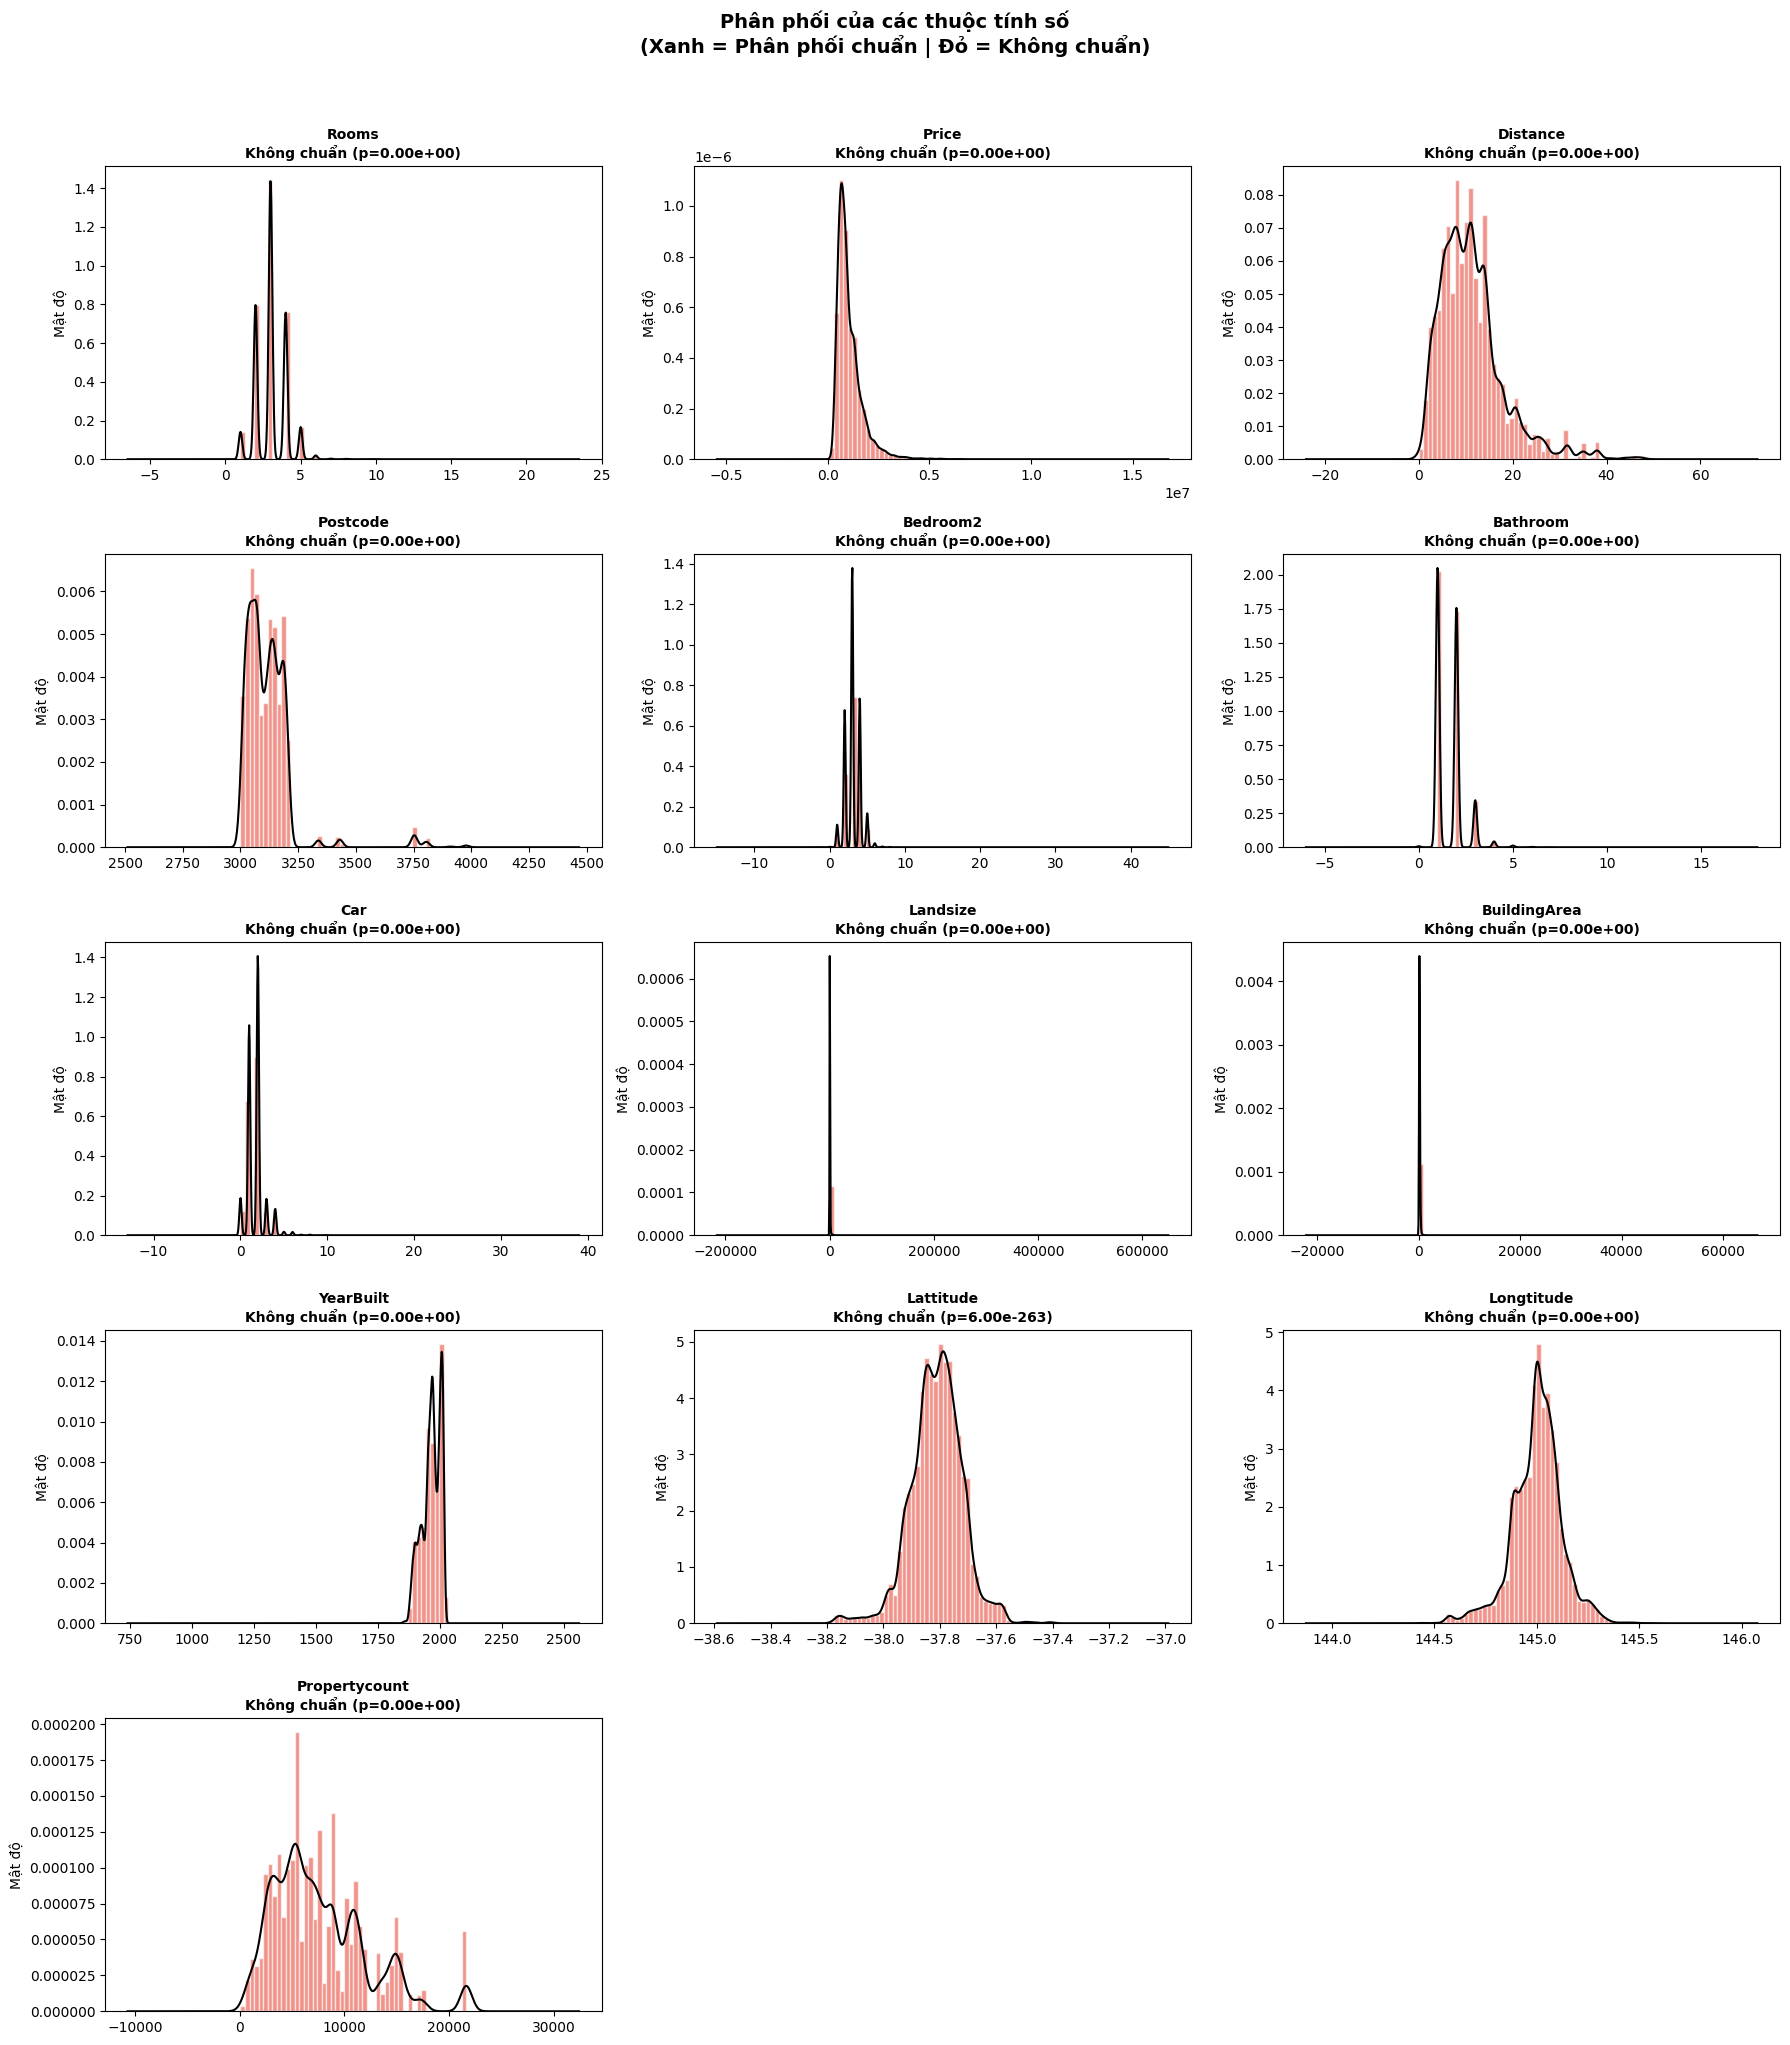

In [6]:
# Vẽ histogram + KDE cho từng thuộc tính số
n_cols_plot = 3
n_rows_plot = (len(numeric_cols) + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, 4 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    data = df[col].dropna()
    
    # Lấy kết quả kiểm định
    row = results_df[results_df['column'] == col].iloc[0]
    is_normal = row['distribution'] == 'Chuẩn (Normal)'
    color = '#2ecc71' if is_normal else '#e74c3c'
    
    # Vẽ histogram + KDE
    ax.hist(data, bins=50, density=True, alpha=0.6, color=color, edgecolor='white')
    if len(data) > 1:
        data.plot.kde(ax=ax, color='black', linewidth=1.5)
    
    # Tiêu đề
    label = 'Chuẩn' if is_normal else 'Không chuẩn'
    p_val = row['p_value']
    ax.set_title(f'{col}\n{label} (p={p_val:.2e})', fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Mật độ')

# Xóa các subplot trống
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Phân phối của các thuộc tính số\n(Xanh = Phân phối chuẩn | Đỏ = Không chuẩn)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Bảng tổng hợp: Phương pháp chuẩn hóa đề xuất

| Loại phân phối | Phương pháp chuẩn hóa | Lý do |
|---|---|---|
| **Phân phối chuẩn** | Z-score (StandardScaler) | Dữ liệu tuân theo phân phối chuẩn, Z-score giữ nguyên hình dạng phân phối |
| **Phân phối không chuẩn** | Min-Max Scaling hoặc Robust Scaler | Min-Max co dữ liệu về [0,1]; Robust Scaler dùng IQR nên ít bị ảnh hưởng bởi outlier |

### Kết luận chi tiết cho từng thuộc tính

In [7]:
# In kết luận chi tiết
print('KẾT LUẬN CHI TIẾT CHO TỪNG THUỘC TÍNH')
print('=' * 100)

for _, row in results_df.iterrows():
    col = row['column']
    print(f'- Thuộc tính: {col}')
    print(f'   Số mẫu hợp lệ      : {row["n_valid"]}')
    print(f'   Kiểm định sử dụng   : {row["test_name"]}')
    print(f'   Giá trị thống kê    : {row["statistic"]:.6f}' if not pd.isna(row['statistic']) else f'   Giá trị thống kê    : N/A')
    print(f'   p-value             : {row["p_value"]:.2e}' if not pd.isna(row['p_value']) else f'   p-value             : N/A')
    print(f'   Phân phối           : {row["distribution"]}')
    print(f'   Chuẩn hóa đề xuất   : {row["normalization_method"]}')
    print(f'   {"─" * 60}')

KẾT LUẬN CHI TIẾT CHO TỪNG THUỘC TÍNH
- Thuộc tính: Rooms
   Số mẫu hợp lệ      : 34857
   Kiểm định sử dụng   : D'Agostino-Pearson
   Giá trị thống kê    : 3356.492772
   p-value             : 0.00e+00
   Phân phối           : Không chuẩn (Non-normal)
   Chuẩn hóa đề xuất   : Min-Max hoặc Robust Scaler
   ────────────────────────────────────────────────────────────
- Thuộc tính: Price
   Số mẫu hợp lệ      : 27247
   Kiểm định sử dụng   : D'Agostino-Pearson
   Giá trị thống kê    : 16076.657444
   p-value             : 0.00e+00
   Phân phối           : Không chuẩn (Non-normal)
   Chuẩn hóa đề xuất   : Min-Max hoặc Robust Scaler
   ────────────────────────────────────────────────────────────
- Thuộc tính: Distance
   Số mẫu hợp lệ      : 34856
   Kiểm định sử dụng   : D'Agostino-Pearson
   Giá trị thống kê    : 10176.518110
   p-value             : 0.00e+00
   Phân phối           : Không chuẩn (Non-normal)
   Chuẩn hóa đề xuất   : Min-Max hoặc Robust Scaler
   ─────────────────────────

## b) Phân tích tương quan đa biến

Vẽ heatmap tương quan **Pearson** và **Spearman**. Xác định các cặp thuộc tính có khả năng đa cộng tuyến mạnh (|r| > 0.9) và đề xuất xử lý.

In [8]:
# Thiết lập style cho biểu đồ
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

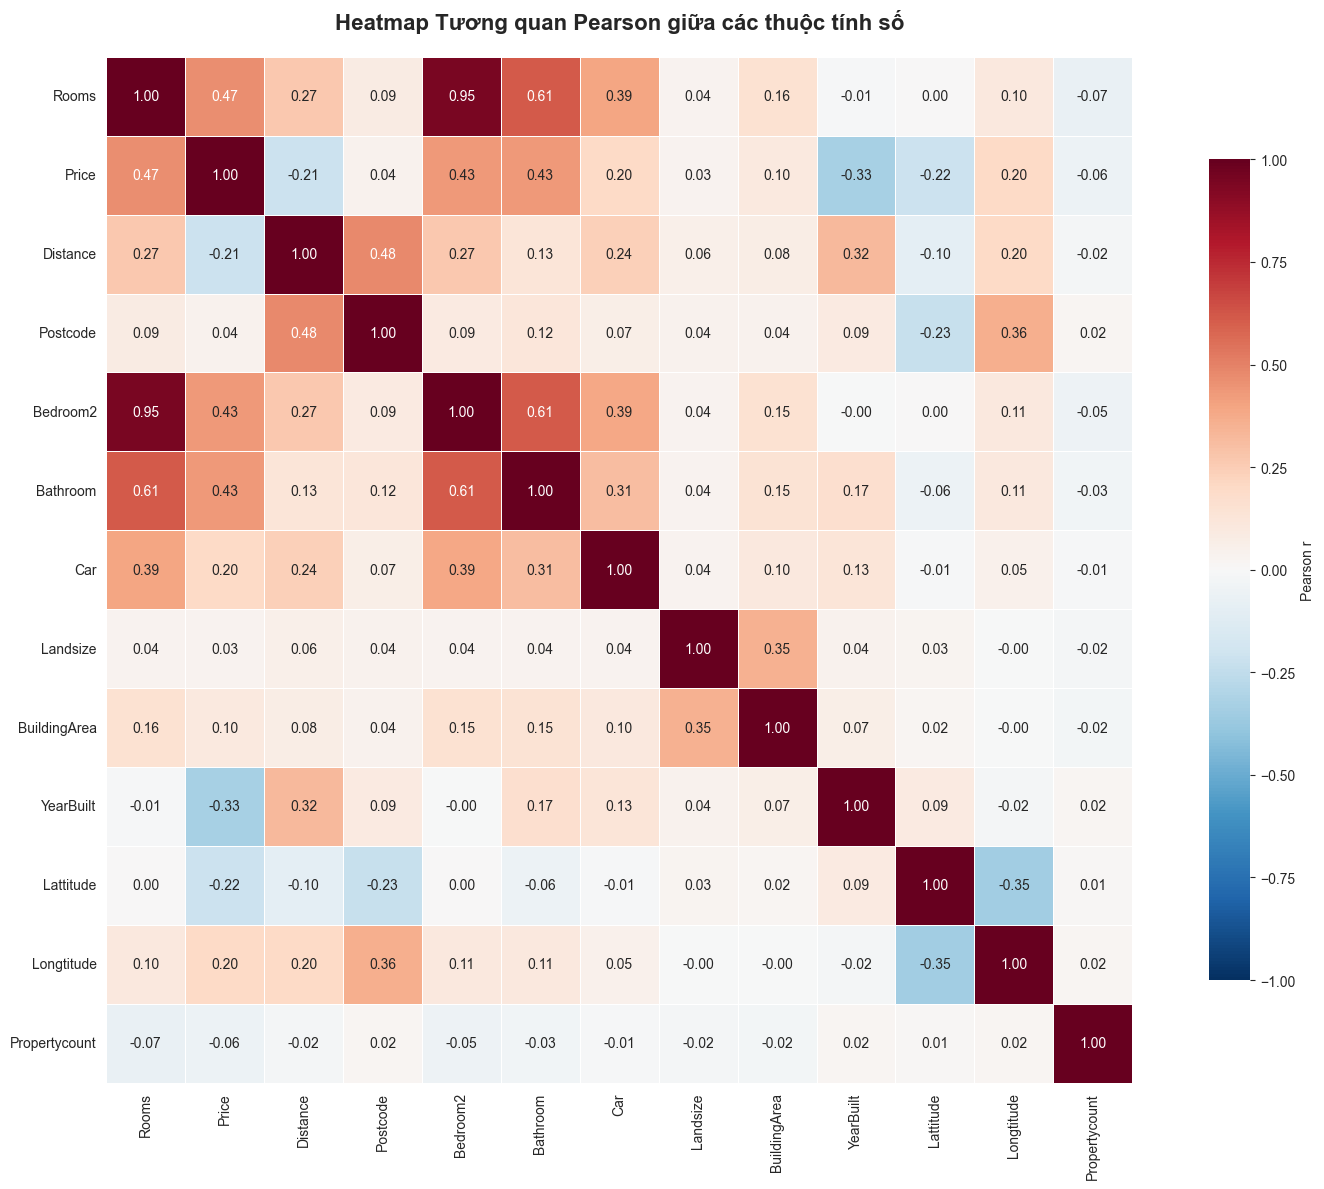

In [9]:
# ===== HEATMAP TƯƠNG QUAN PEARSON =====
# Chỉ lấy các cột số gốc 
num_df = df[numeric_cols]
pearson_corr = num_df.corr(method='pearson')

fig, ax = plt.subplots(figsize=(16, 12))

sns.heatmap(
    pearson_corr,

    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
    ax=ax
)
ax.set_title('Heatmap Tương quan Pearson giữa các thuộc tính số', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

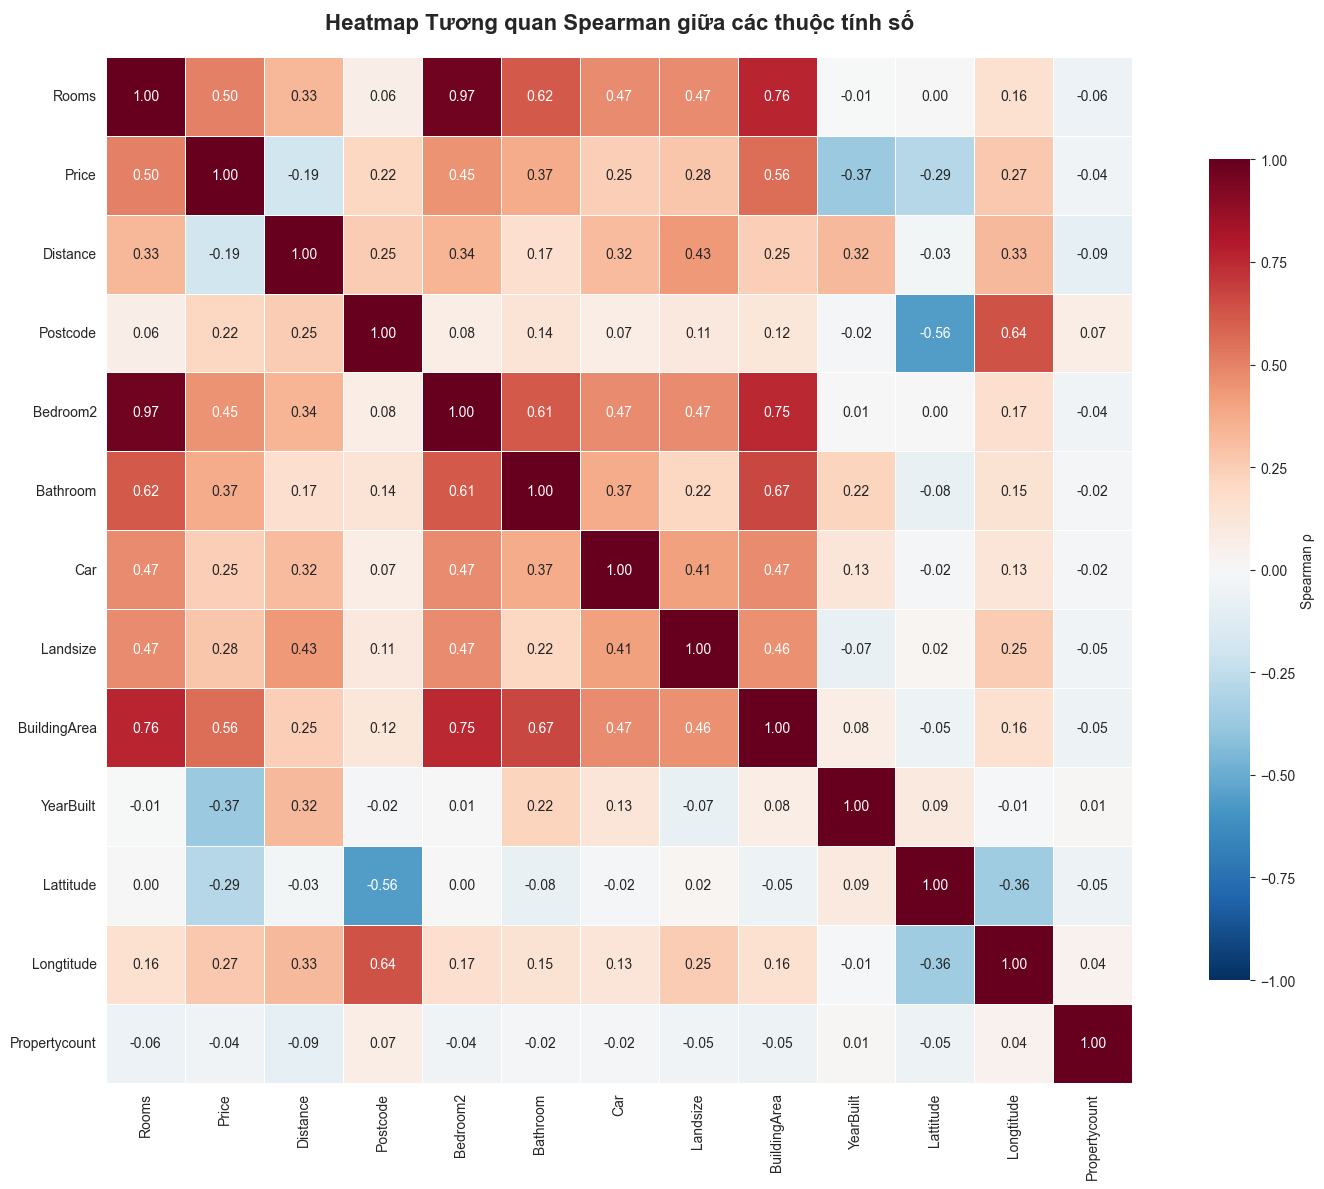

In [10]:
# ===== HEATMAP TƯƠNG QUAN SPEARMAN =====
spearman_corr = num_df.corr(method='spearman')

fig, ax = plt.subplots(figsize=(16, 12))

sns.heatmap(
    spearman_corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Spearman ρ'},
    ax=ax
)
ax.set_title('Heatmap Tương quan Spearman giữa các thuộc tính số', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [11]:
# ===== XÁC ĐỊNH CÁC CẶP ĐA CỘNG TUYẾN MẠNH (|r| > 0.9) =====
threshold = 0.9

def find_high_corr_pairs(corr_matrix, threshold=0.9):
    """Tìm các cặp có tương quan cao hơn ngưỡng."""
    pairs = []
    cols = corr_matrix.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            r = corr_matrix.iloc[i, j]
            if abs(r) > threshold:
                pairs.append({
                    'Feature 1': cols[i],
                    'Feature 2': cols[j],
                    'Correlation': round(r, 4)
                })
    return pd.DataFrame(pairs)

print('=' * 60)
print('CÁC CẶP ĐA CỘNG TUYẾN MẠNH (|r| > 0.9)')
print('=' * 60)

print('\n--- Theo Pearson ---')
high_pearson = find_high_corr_pairs(pearson_corr, threshold)
if len(high_pearson) > 0:
    display(high_pearson)
else:
    print('Không tìm thấy cặp nào có |r| > 0.9 theo Pearson.')

print('\n--- Theo Spearman ---')
high_spearman = find_high_corr_pairs(spearman_corr, threshold)
if len(high_spearman) > 0:
    display(high_spearman)
else:
    print('Không tìm thấy cặp nào có |ρ| > 0.9 theo Spearman.')

CÁC CẶP ĐA CỘNG TUYẾN MẠNH (|r| > 0.9)

--- Theo Pearson ---


,Feature 1,Feature 2,Correlation
0,Rooms,Bedroom2,0.9468



--- Theo Spearman ---


,Feature 1,Feature 2,Correlation
0,Rooms,Bedroom2,0.97


### Đề xuất xử lý đa cộng tuyến

Khi phát hiện các cặp thuộc tính có |r| > 0.9, ta có thể áp dụng các phương pháp sau:

1. **Loại bỏ một trong hai biến** trong cặp có tương quan cao – giữ lại biến có ý nghĩa nghiệp vụ hơn hoặc có ít missing values hơn.
2. **PCA (Principal Component Analysis)** – giảm chiều dữ liệu bằng cách kết hợp các biến tương quan cao thành các thành phần chính.
3. **VIF (Variance Inflation Factor)** – tính VIF cho từng biến để xác nhận mức độ đa cộng tuyến và loại bỏ biến có VIF > 10.
4. **Regularization** – sử dụng các mô hình có chính quy hóa (Lasso, Ridge, Elastic Net) thay vì hồi quy thông thường.

**Ví dụ cụ thể**: Nếu `Rooms` và `Bedroom2` có tương quan rất cao (gần 1.0), ta có thể loại bỏ `Bedroom2`
vì `Rooms` đã phản ánh thông tin tương tự. Thực tế trong dataset, cột `Bedroom2` là thông tin về số phòng ngủ được thu thập ở 1 nguồn khác, nên việc loại bỏ cột `Bedroom2` là hoàn toàn hợp lý.

## c) Phân tích giá trị thiếu

- Trực quan hóa ma trận thiếu dữ liệu bằng thư viện `missingno`.
- Kiểm định giả thuyết MCAR bằng Little's MCAR test.
- Phân loại cơ chế thiếu dữ liệu (MCAR / MAR / MNAR) và giải thích.

In [12]:
# Thống kê giá trị thiếu
missing_stats = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2),
    'Dtype': df.dtypes
})
missing_stats = missing_stats[missing_stats['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f'Tổng số thuộc tính có giá trị thiếu: {len(missing_stats)}/{len(df.columns)}')
print(f'Tổng số giá trị thiếu trong dataset: {df.isnull().sum().sum()}')
print(f'Tỷ lệ thiếu trung bình: {(df.isnull().sum().sum() / df.size * 100):.2f}%')
print()
display(missing_stats)

Tổng số thuộc tính có giá trị thiếu: 14/21
Tổng số giá trị thiếu trong dataset: 100975
Tỷ lệ thiếu trung bình: 13.79%



,Missing Count,Missing %,Dtype
BuildingArea,21115,60.58,float64
YearBuilt,19306,55.39,float64
Landsize,11810,33.88,float64
Car,8728,25.04,float64
Bathroom,8226,23.60,float64
Bedroom2,8217,23.57,float64
Longtitude,7976,22.88,float64
Lattitude,7976,22.88,float64
Price,7610,21.83,float64
CouncilArea,3,0.01,object


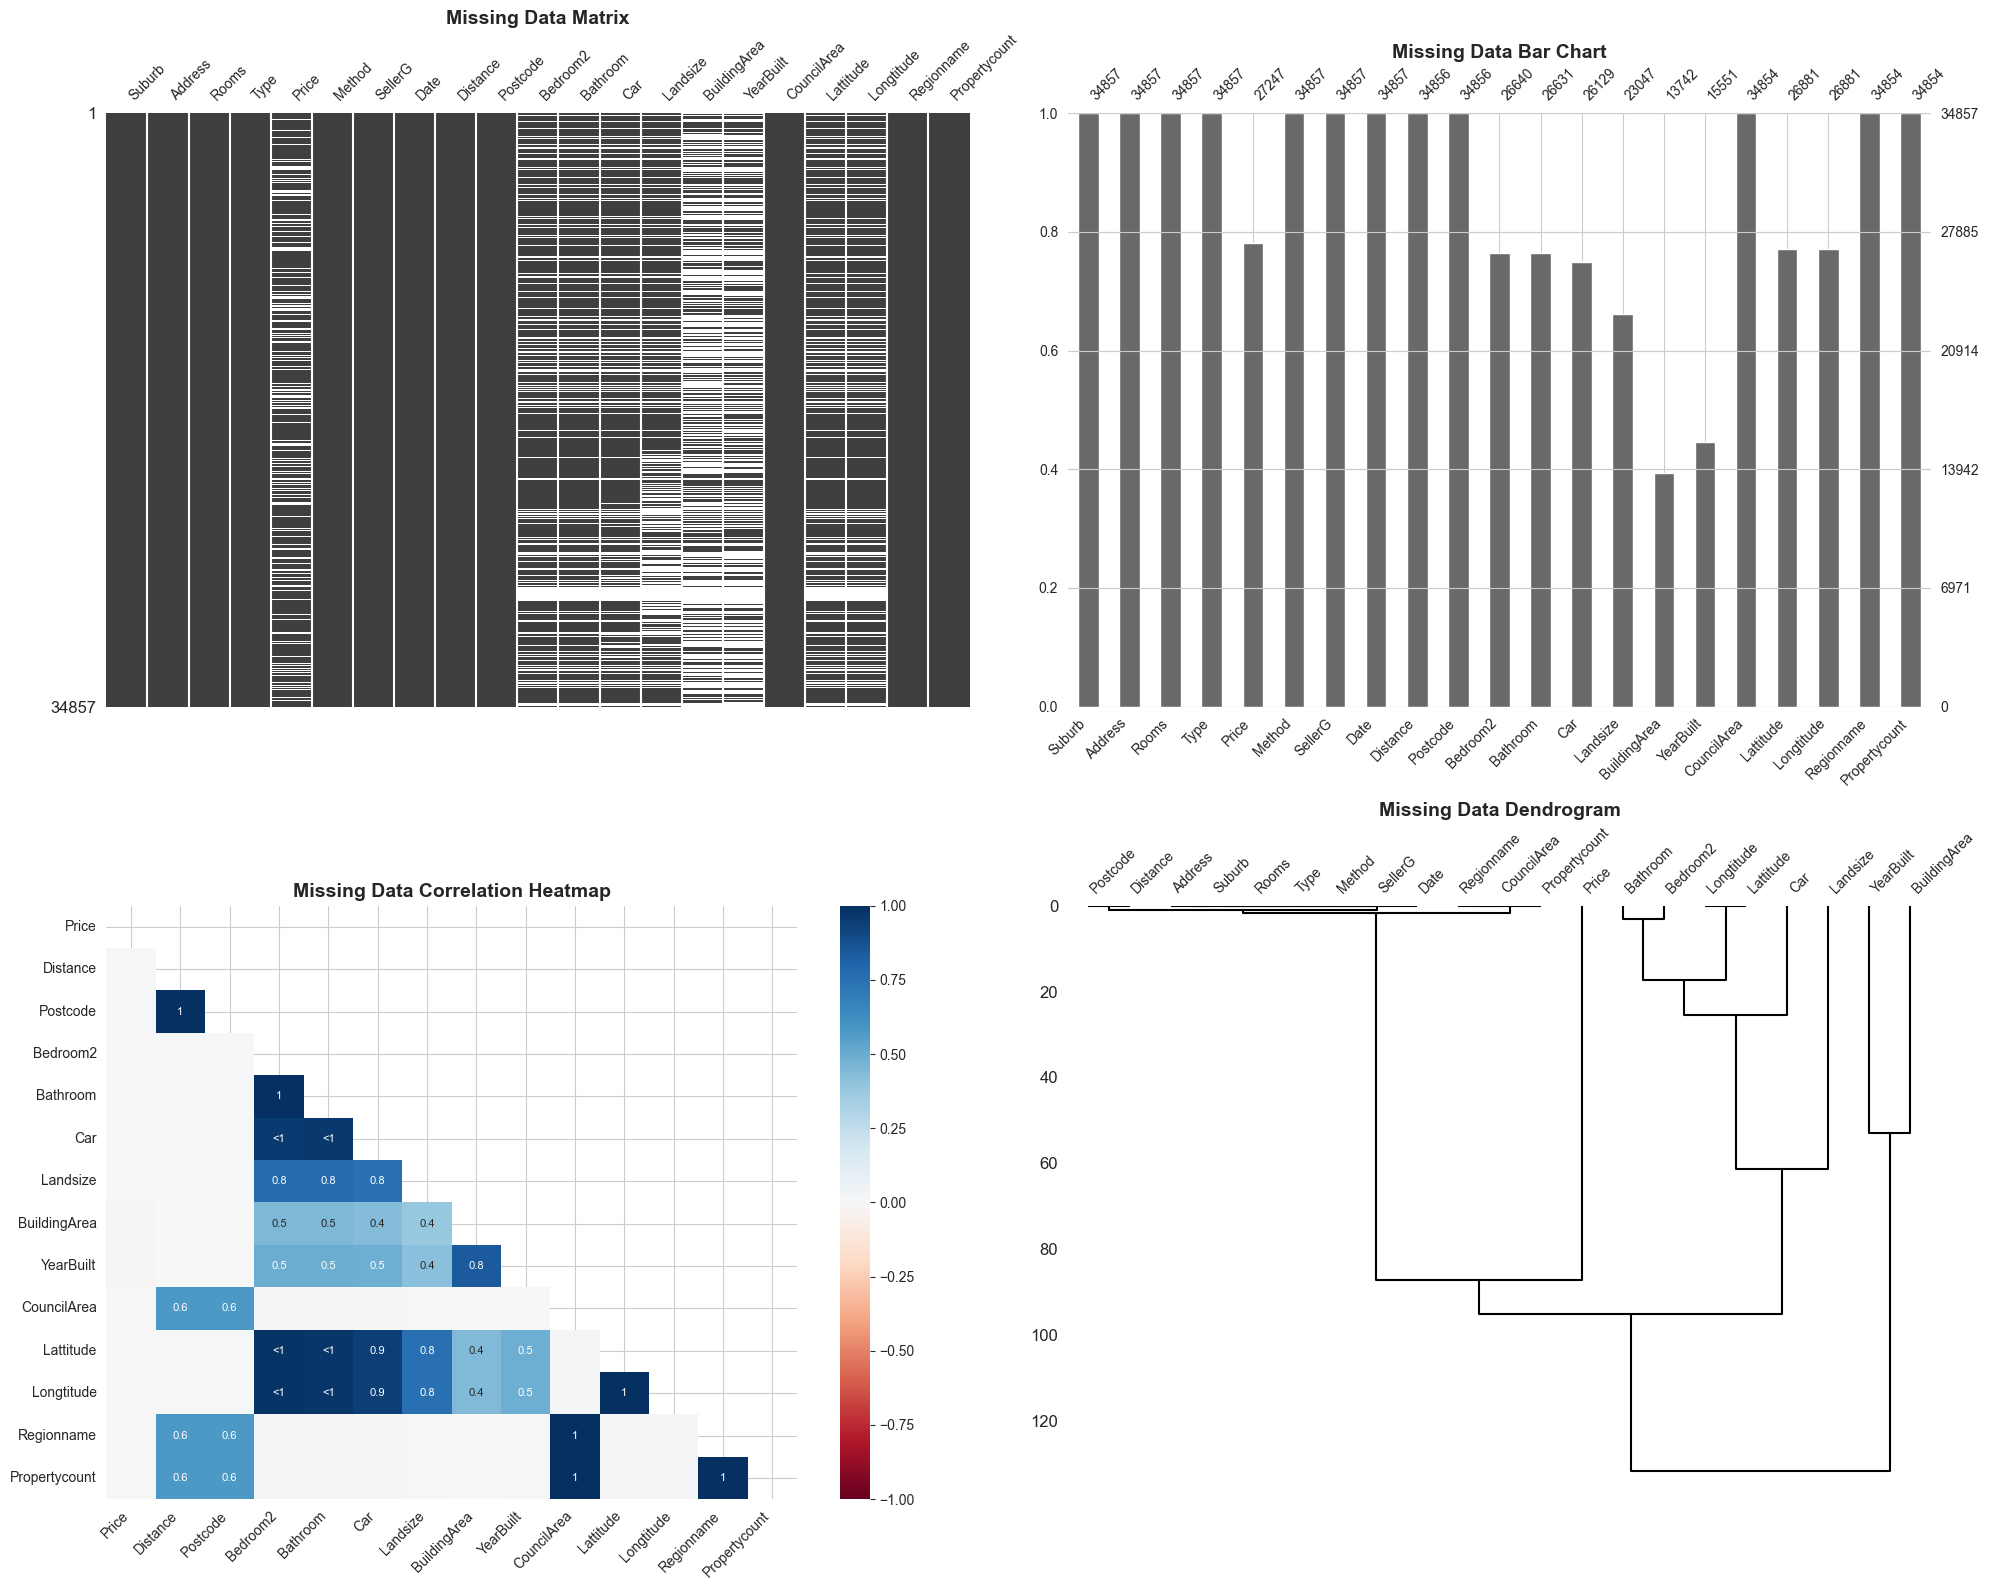

In [13]:
# ===== MA TRẬN THIẾU DỮ LIỆU (MISSING DATA MATRIX) =====
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# 1. Matrix plot – trực quan hóa vị trí thiếu
plt.sca(axes[0, 0])
msno.matrix(df, ax=axes[0, 0], sparkline=False, fontsize=10)
axes[0, 0].set_title('Missing Data Matrix', fontsize=14, fontweight='bold')

# 2. Bar chart – tỷ lệ hiện diện của mỗi cột
plt.sca(axes[0, 1])
msno.bar(df, ax=axes[0, 1], fontsize=10)
axes[0, 1].set_title('Missing Data Bar Chart', fontsize=14, fontweight='bold')

# 3. Heatmap – tương quan giữa các giá trị thiếu
plt.sca(axes[1, 0])
msno.heatmap(df, ax=axes[1, 0], fontsize=10)
axes[1, 0].set_title('Missing Data Correlation Heatmap', fontsize=14, fontweight='bold')

# 4. Dendrogram – phân nhóm các cột theo pattern thiếu
plt.sca(axes[1, 1])
msno.dendrogram(df, ax=axes[1, 1], fontsize=10)
axes[1, 1].set_title('Missing Data Dendrogram', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
def littles_mcar_test(df):
    """
    Triển khai Little's MCAR test
    """
    dataset = df.copy()
    vars = dataset.columns
    n = len(dataset)
    k = len(vars)

    # 1. Ước lượng trung bình và hiệp phương sai tổng thể (Maximum Likelihood)
    mu_global = dataset.mean()
    # Fillna tạm thời bằng mean để tính covariance matrix ổn định hơn
    sigma_global = dataset.fillna(mu_global).cov()
    
    # 2. Xác định các "Missing Patterns"
    indicator = dataset.isnull().astype(int)
    unique_patterns = indicator.drop_duplicates()
    
    d2 = 0  # Giá trị thống kê chi-square (Distance)
    df_degrees = 0 # Bậc tự do
    
    for _, pattern in unique_patterns.iterrows():
        # Lọc các hàng khớp với pattern 
        rows_idx = indicator[(indicator == pattern).all(axis=1)].index
        n_j = len(rows_idx)
        
        # Các cột không bị thiếu trong pattern 
        observed_cols = vars[pattern == 0]
        
        if len(observed_cols) == 0 or len(observed_cols) == k:
            # Nếu pattern là thiếu hết hoặc không thiếu gì, bậc tự do không tăng
            if len(observed_cols) == k:
                # Vẫn tính toán cho trường hợp không thiếu gì (baseline)
                # nhưng thực tế hiệu số (mean_j - mu_global) sẽ bằng 0
                pass
            continue
            
        # Lấy dữ liệu của pattern này tại các cột quan sát được
        sub_data = dataset.loc[rows_idx, observed_cols]
        mu_j = sub_data.mean()
        
        # Lấy phần tương ứng của mu_global và sigma_global
        mu_global_subset = mu_global[observed_cols]
        sigma_global_subset = sigma_global.loc[observed_cols, observed_cols]
        
        # Tính Mahalanobis distance trọng số cho pattern này
        try:
            diff = (mu_j - mu_global_subset).values
            inv_sigma = np.linalg.pinv(sigma_global_subset) # Dùng pseudo-inverse cho ổn định
            d2 += n_j * diff.T @ inv_sigma @ diff
            df_degrees += len(observed_cols)
        except np.linalg.LinAlgError:
            continue

    # Bậc tự do = Tổng số biến quan sát được trong các pattern - số biến gốc
    df_degrees = df_degrees - k
    p_value = 1 - stats.chi2.cdf(d2, df=df_degrees)
    
    return d2, df_degrees, p_value


Đang phân tích biểu đồ missingness...


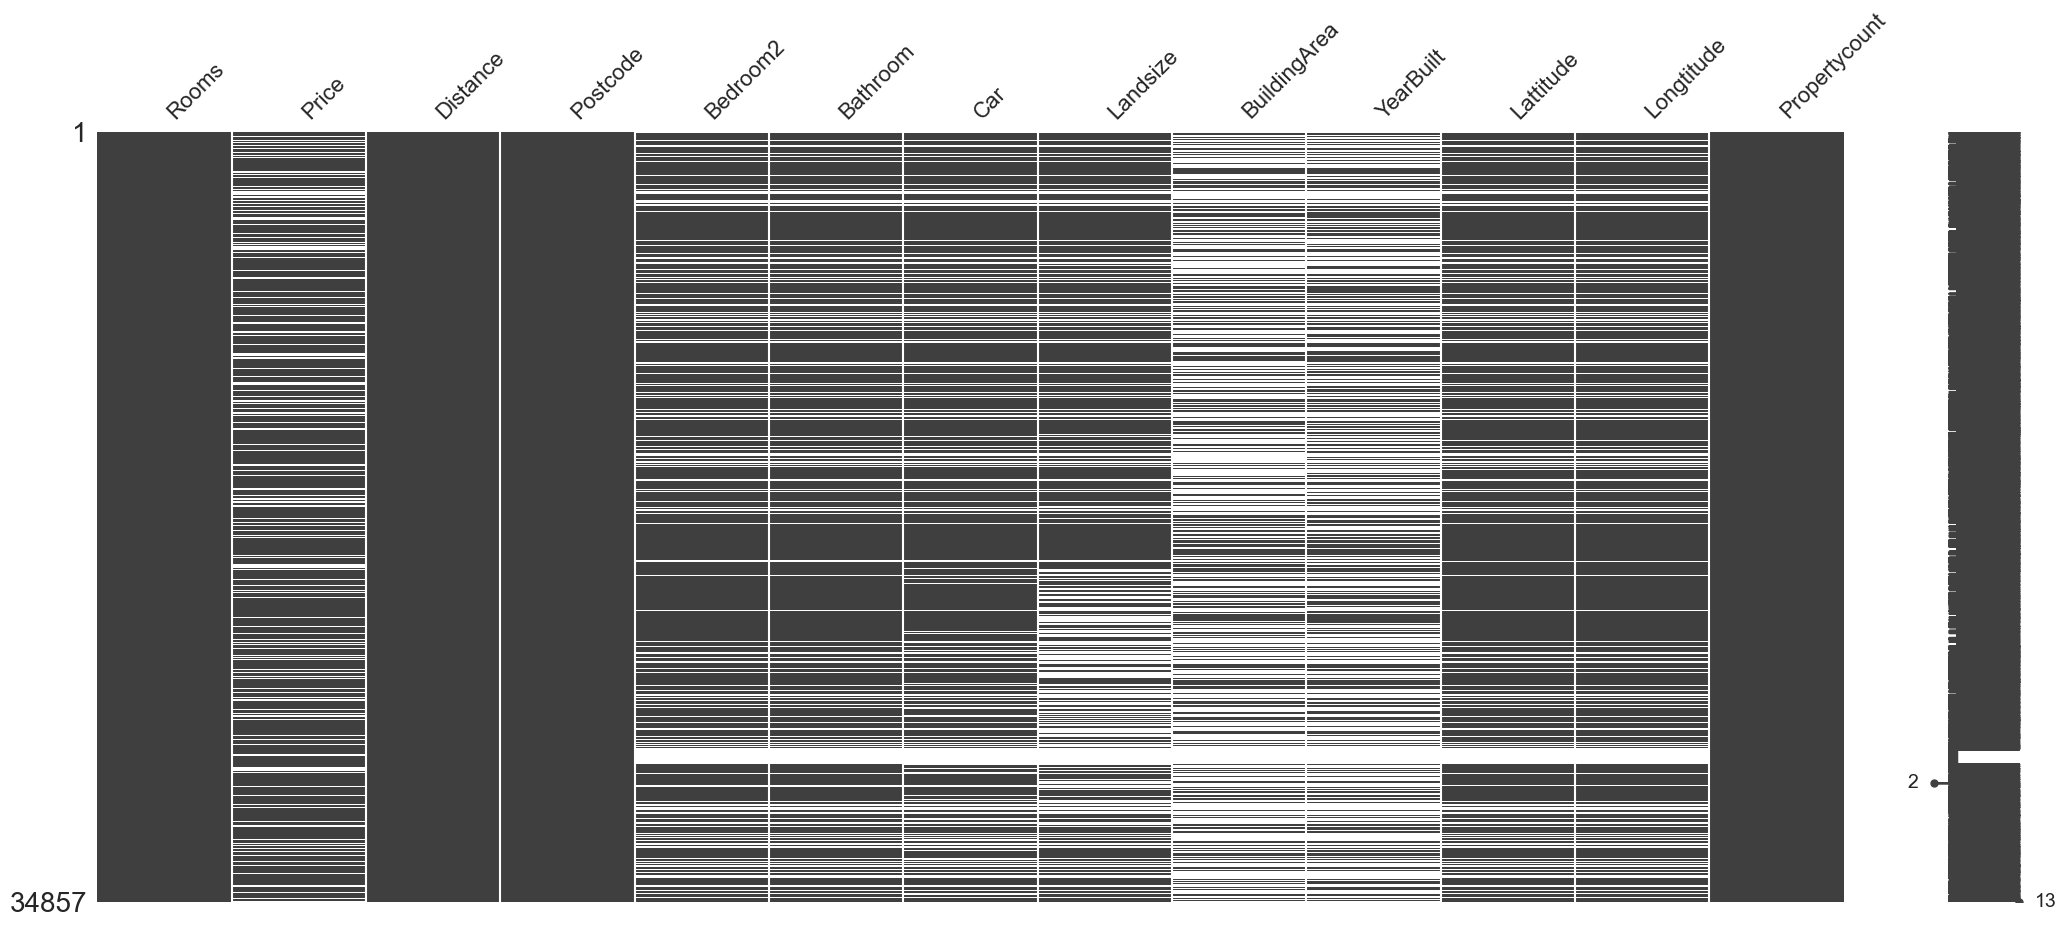

Đang thực hiện Little's MCAR Test trên 12 cột...
KẾT QUẢ LITTLE'S MCAR TEST (Manual Implementation)
Chi-square Statistic: 4586.6893
Bậc tự do (df): 385
p-value: 0.000000
------------------------------------------------------------
Kết luận: p-value ≤ 0.05. BÁC BỎ H0.
→ Dữ liệu KHÔNG PHẢI MCAR. Có thể là MAR hoặc MNAR.


In [15]:
# 1. Trực quan hóa pattern trước (Dùng thư viện missingno cho phép)
print("Đang phân tích biểu đồ missingness...")
msno.matrix(df[numeric_cols])
plt.show()

# 2. Thực hiện kiểm định
num_with_missing = df[numeric_cols].loc[:, df[numeric_cols].isnull().any()]

if num_with_missing.empty:
    print("Không có giá trị thiếu trong các cột số.")
else:
    print(f"Đang thực hiện Little's MCAR Test trên {num_with_missing.shape[1]} cột...")
    chi_stat, degrees, p_val = littles_mcar_test(num_with_missing)

    print('=' * 60)
    print("KẾT QUẢ LITTLE'S MCAR TEST (Manual Implementation)")
    print('=' * 60)
    print(f'Chi-square Statistic: {chi_stat:.4f}')
    print(f'Bậc tự do (df): {degrees}')
    print(f'p-value: {p_val:.6f}')
    print('-' * 60)

    alpha = 0.05
    if p_val > alpha:
        print(f"Kết luận: p-value > {alpha}. KHÔNG BÁC BỎ H0.")
        print("→ Dữ liệu thiếu có khả năng là MCAR (Missing Completely At Random).")
    else:
        print(f"Kết luận: p-value ≤ {alpha}. BÁC BỎ H0.")
        print("→ Dữ liệu KHÔNG PHẢI MCAR. Có thể là MAR hoặc MNAR.")

Các cột có giá trị thiếu: ['Price', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude', 'Longtitude', 'Regionname', 'Propertycount']



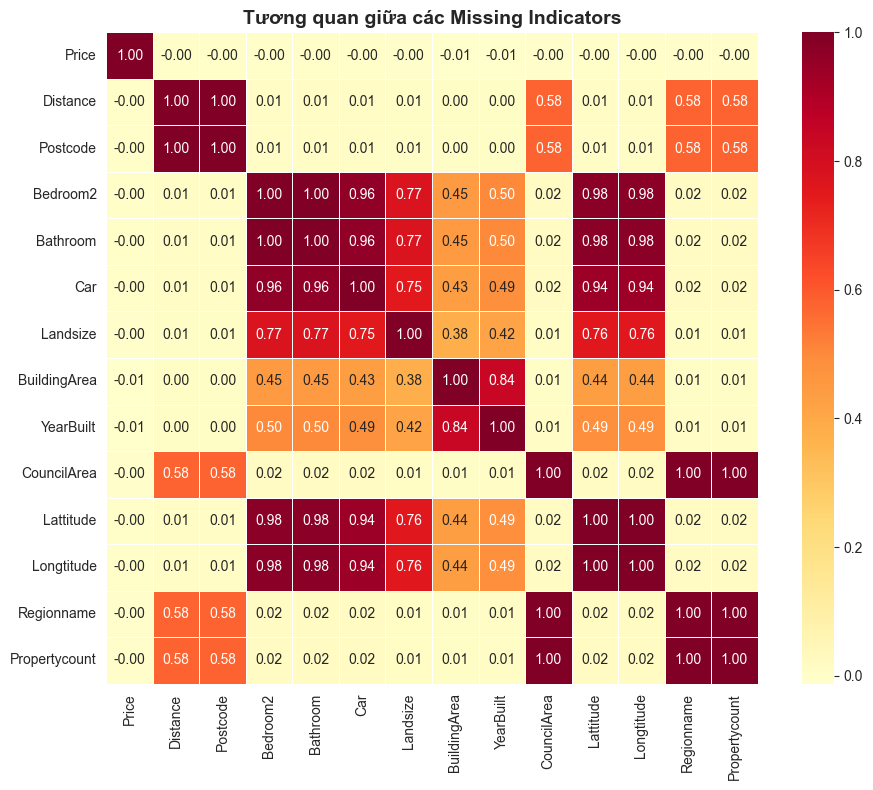


Nhận xét:
- Nếu missing indicators có tương quan CAO → các cột thiếu cùng lúc → gợi ý MAR hoặc MNAR
- Nếu missing indicators KHÔNG tương quan → thiếu ngẫu nhiên → gợi ý MCAR


In [17]:
# ===== PHÂN TÍCH SÂU CƠ CHẾ THIẾU DỮ LIỆU =====
# Kiểm tra mối liên hệ giữa các cột thiếu với nhau (hỗ trợ phân loại MAR vs MNAR)

missing_cols_all = df.columns[df.isnull().any()].tolist()
print('Các cột có giá trị thiếu:', missing_cols_all)
print()

# Tạo ma trận tương quan giữa các missing indicators
missing_indicators = df[missing_cols_all].isnull().astype(int)
missing_corr = missing_indicators.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    missing_corr,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Tương quan giữa các Missing Indicators', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print('Nhận xét:')
print('- Nếu missing indicators có tương quan CAO → các cột thiếu cùng lúc → gợi ý MAR hoặc MNAR')
print('- Nếu missing indicators KHÔNG tương quan → thiếu ngẫu nhiên → gợi ý MCAR')

### Phân loại cơ chế thiếu dữ liệu và giải thích

| Cơ chế | Định nghĩa | Ví dụ trong dataset |
|--------|-----------|--------------------|
| **MCAR** (Missing Completely At Random) | Xác suất thiếu **không phụ thuộc** vào bất kỳ biến quan sát hay không quan sát nào. | Dữ liệu bị mất do lỗi nhập liệu ngẫu nhiên. |
| **MAR** (Missing At Random) | Xác suất thiếu **phụ thuộc vào các biến quan sát được** nhưng không phụ thuộc vào chính giá trị bị thiếu. | `BuildingArea` thiếu nhiều ở nhà cũ (`YearBuilt` thấp) do hồ sơ xây dựng cũ không được lưu trữ. |
| **MNAR** (Missing Not At Random) | Xác suất thiếu **phụ thuộc vào chính giá trị bị thiếu**. | `Price` thiếu vì người bán không muốn công khai giá bán (giá quá cao hoặc quá thấp). |

#### Nhận xét cho Melbourne Housing Dataset:

- **`Price`**: Thiếu ~21.8% dữ liệu. Các phương thức bán nhà như `VB` (vendor bid), `PI` (passed in) thường không có giá bán cuối cùng → khả năng cao là **MAR** (phụ thuộc vào `Method`).
- **`BuildingArea`** & **`YearBuilt`**: Thiếu nhiều (~56-60%). Các bất động sản cũ hoặc landsize rất nhỏ thường không có thông tin diện tích xây dựng → có thể là **MAR** (phụ thuộc vào tuổi nhà) hoặc **MNAR**.
- **`Lattitude`**, **`Longtitude`**, **`Car`**, **`Bathroom`**, **`Bedroom2`**: Thiếu quanh mức ~23-25%. Các biến này thường bị thiếu đồng loạt trong cùng các mẩu tin đăng bán kém chi tiết từ ngày xưa. Do đó khả năng cao chúng là MAR (Thiếu chung với nhau tạo thành một pattern riêng như bạn đã thấy trong Heatmap của Missingno). Xử lý có thể dùng thuật toán điền (Imputation) đa biến.

- **`CouncilArea`**, **`Regionname`** (và một số thuộc tính lẻ tẻ): Thiếu RẤT ít (~0.01%). Việc thiếu chủ yếu do lỗi trích xuất text vô thưởng vô phạt $\Rightarrow$ Là dữ liệu MCAR thực sự. Có thể thẳng tay Drop NA các dòng nảy mà không ảnh hưởng gì tới độ lệch mẫ

#### Đề xuất xử lý:
- **MCAR**: Có thể loại bỏ hàng (listwise deletion) hoặc mean/median imputation mà không gây bias.
- **MAR**: Sử dụng phương pháp imputation phức tạp hơn (Multiple Imputation, KNN Imputation, regression imputation) dựa trên các biến quan sát liên quan.
- **MNAR**: Cần xem xét domain knowledge, có thể cần tạo biến indicator cho việc thiếu dữ liệu hoặc sử dụng mô hình chuyên biệt.